# NDN IF Model Result Analysis

This notebook performs detailed visual analysis of all CSV outputs generated by `if_model.ipynb`.

Covered files:
- `Results/dataset_comparison_summary.csv`
- `Results/cross_dataset_nodewise_comparison.csv`
- `Results/training_scored.csv`
- `Results/detailed_analysis/*_nodewise_stats.csv`
- `Results/detailed_analysis/*_scored.csv`
- `Results/detailed_analysis/*_feature_importance.csv`

Outputs from this notebook are saved under:
- `Results/analysis_charts/`

In [14]:
import os
from pathlib import Path
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RESULTS_DIR = Path("../Results")
DETAIL_DIR = RESULTS_DIR / "detailed_analysis"
ANALYSIS_OUT = RESULTS_DIR / "analysis_charts"
ANALYSIS_OUT.mkdir(parents=True, exist_ok=True)

DATASET_ORDER = ["normal", "anomaly", "mixed", "cp_attack", "ifa_attack"]

print(f"Results dir: {RESULTS_DIR.resolve()}")
print(f"Detailed dir: {DETAIL_DIR.resolve()}")
print(f"Analysis output dir: {ANALYSIS_OUT.resolve()}")

Results dir: /Users/ankitpokhrel/Desktop/NDN-Toolkit/Results
Detailed dir: /Users/ankitpokhrel/Desktop/NDN-Toolkit/Results/detailed_analysis
Analysis output dir: /Users/ankitpokhrel/Desktop/NDN-Toolkit/Results/analysis_charts


In [15]:
# Load all CSV artifacts
summary_df = pd.read_csv(RESULTS_DIR / "dataset_comparison_summary.csv")
cross_node_df = pd.read_csv(RESULTS_DIR / "cross_dataset_nodewise_comparison.csv")
training_scored_df = pd.read_csv(RESULTS_DIR / "training_scored.csv")

nodewise_stats = {}
scored_data = {}
feature_importance = {}

for ds in DATASET_ORDER:
    nodewise_stats[ds] = pd.read_csv(DETAIL_DIR / f"{ds}_nodewise_stats.csv")
    scored_data[ds] = pd.read_csv(DETAIL_DIR / f"{ds}_scored.csv")
    feature_importance[ds] = pd.read_csv(DETAIL_DIR / f"{ds}_feature_importance.csv")

print("Loaded files successfully.")
print("summary_df:", summary_df.shape)
print("cross_node_df:", cross_node_df.shape)
print("training_scored_df:", training_scored_df.shape)
for ds in DATASET_ORDER:
    print(f"{ds}: nodewise={nodewise_stats[ds].shape}, scored={scored_data[ds].shape}, fi={feature_importance[ds].shape}")

Loaded files successfully.
summary_df: (5, 10)
cross_node_df: (61, 9)
training_scored_df: (126423, 15)
normal: nodewise=(13, 8), scored=(126423, 15), fi=(10, 2)
anomaly: nodewise=(13, 8), scored=(36749, 15), fi=(10, 2)
mixed: nodewise=(13, 8), scored=(163172, 15), fi=(10, 2)
cp_attack: nodewise=(12, 8), scored=(16216, 15), fi=(10, 2)
ifa_attack: nodewise=(10, 8), scored=(20533, 15), fi=(10, 2)


In [16]:
# Quick data quality checks
missing_summary = summary_df.isna().sum().sort_values(ascending=False)
missing_cross = cross_node_df.isna().sum().sort_values(ascending=False)

print("Missing values (summary_df):")
print(missing_summary[missing_summary > 0] if (missing_summary > 0).any() else "None")
print("\nMissing values (cross_node_df):")
print(missing_cross[missing_cross > 0] if (missing_cross > 0).any() else "None")

for ds in DATASET_ORDER:
    missing_scored = scored_data[ds].isna().sum().sum()
    missing_nodewise = nodewise_stats[ds].isna().sum().sum()
    missing_fi = feature_importance[ds].isna().sum().sum()
    print(f"{ds}: missing(scored={missing_scored}, nodewise={missing_nodewise}, feature_importance={missing_fi})")

Missing values (summary_df):
None

Missing values (cross_node_df):
None
normal: missing(scored=0, nodewise=0, feature_importance=0)
anomaly: missing(scored=0, nodewise=0, feature_importance=0)
mixed: missing(scored=0, nodewise=0, feature_importance=0)
cp_attack: missing(scored=0, nodewise=0, feature_importance=0)
ifa_attack: missing(scored=0, nodewise=0, feature_importance=0)


,dataset_name,n_samples,n_nodes,n_anomalies,anomaly_pct,mean_score,std_score,min_score,max_score,threshold
0,normal,126423,13,1234,0.976088,0.188531,0.073374,-0.146181,0.283235,0.0
2,mixed,163172,13,1253,0.767901,0.201557,0.071836,-0.146181,0.283235,0.0
3,cp_attack,16216,12,11,0.067834,0.247390,0.041661,-0.049353,0.283235,0.0
1,anomaly,36749,13,19,0.051702,0.246366,0.042431,-0.049353,0.283235,0.0
4,ifa_attack,20533,10,8,0.038962,0.245558,0.043012,-0.043504,0.283235,0.0


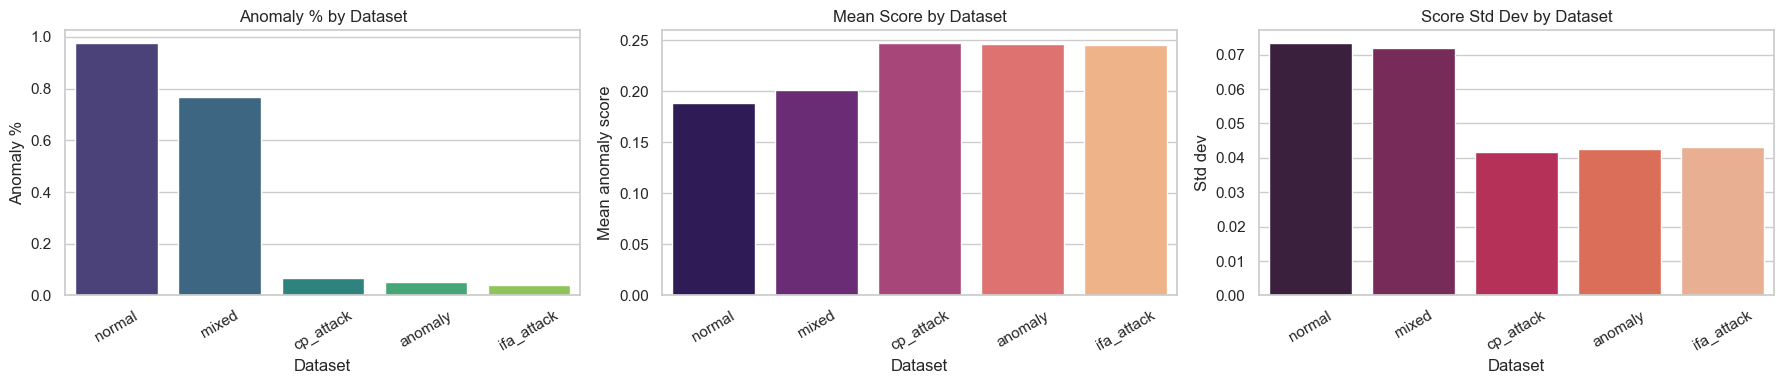

In [17]:
# 1) dataset_comparison_summary.csv analysis
summary_disp = summary_df.copy()
summary_disp = summary_disp.sort_values("anomaly_pct", ascending=False)
display(summary_disp)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.barplot(data=summary_disp, x="dataset_name", y="anomaly_pct", hue="dataset_name", ax=axes[0], palette="viridis", legend=False)
axes[0].set_title("Anomaly % by Dataset")
axes[0].set_xlabel("Dataset")
axes[0].set_ylabel("Anomaly %")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_disp, x="dataset_name", y="mean_score", hue="dataset_name", ax=axes[1], palette="magma", legend=False)
axes[1].set_title("Mean Score by Dataset")
axes[1].set_xlabel("Dataset")
axes[1].set_ylabel("Mean anomaly score")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_disp, x="dataset_name", y="std_score", hue="dataset_name", ax=axes[2], palette="rocket", legend=False)
axes[2].set_title("Score Std Dev by Dataset")
axes[2].set_xlabel("Dataset")
axes[2].set_ylabel("Std dev")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(ANALYSIS_OUT / "01_dataset_summary_bars.png", dpi=150, bbox_inches="tight")
plt.show()

,dataset,node,n_samples,n_anomalies,anomaly_pct,mean_score,std_score,min_score,max_score
25,anomaly,r4,3402,8,0.24,0.2448,0.0471,-0.0494,0.2832
24,anomaly,r3,3402,4,0.12,0.2434,0.0469,-0.0435,0.2832
23,anomaly,r2,3406,3,0.09,0.2483,0.0441,-0.0398,0.2832
17,anomaly,c4,1351,1,0.07,0.2458,0.0428,-0.0029,0.2828
22,anomaly,r1,3405,2,0.06,0.2431,0.0471,-0.0396,0.2832
50,cp_attack,r4,1350,4,0.30,0.2428,0.0500,-0.0494,0.2832
48,cp_attack,r2,1352,3,0.22,0.2476,0.0459,-0.0398,0.2832
49,cp_attack,r3,1350,2,0.15,0.2450,0.0468,-0.0396,0.2832
42,cp_attack,c4,1351,1,0.07,0.2458,0.0428,-0.0029,0.2828
47,cp_attack,r1,1351,1,0.07,0.2467,0.0468,-0.0396,0.2832


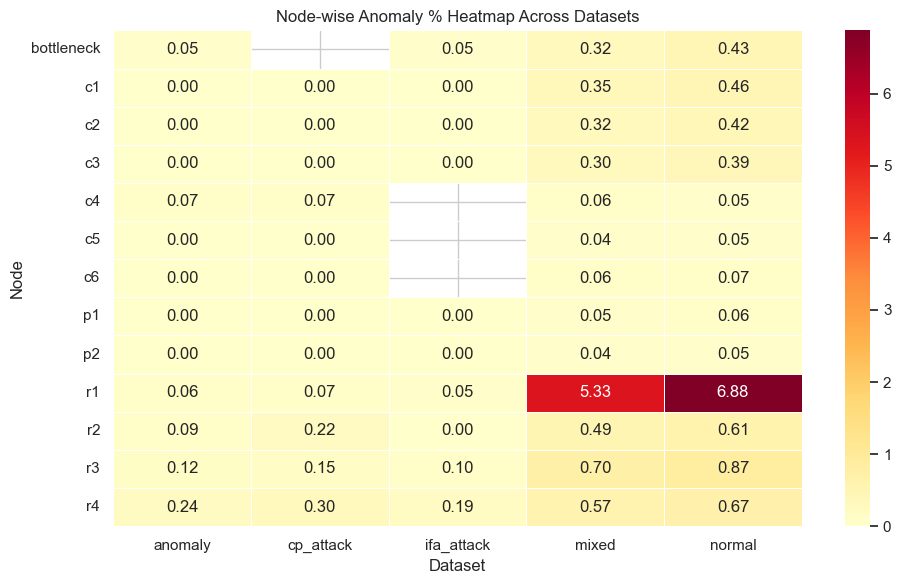

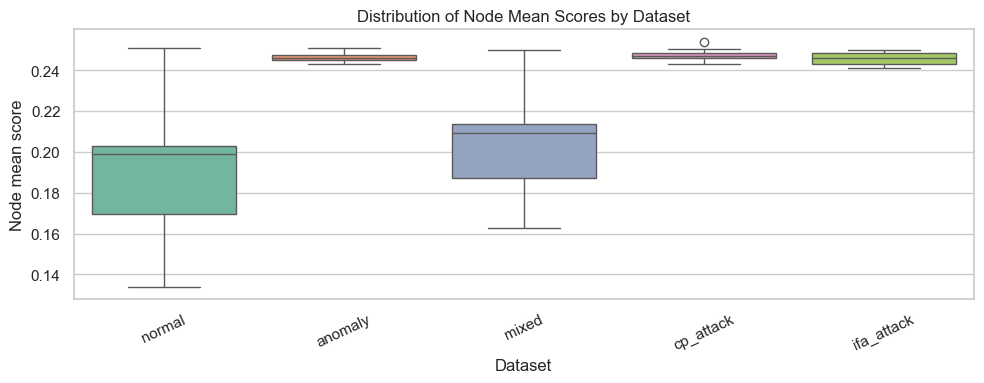

In [18]:
# 2) cross_dataset_nodewise_comparison.csv analysis
cross_disp = cross_node_df.copy()

# Top anomalous nodes per dataset
top_nodes = (
    cross_disp.sort_values(["dataset", "anomaly_pct"], ascending=[True, False])
    .groupby("dataset")
    .head(5)
)
display(top_nodes)

# Heatmap: node vs dataset anomaly_pct
heat_df = cross_disp.pivot_table(index="node", columns="dataset", values="anomaly_pct", aggfunc="mean")

plt.figure(figsize=(10, max(6, 0.45 * len(heat_df))))
sns.heatmap(heat_df, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Node-wise Anomaly % Heatmap Across Datasets")
plt.xlabel("Dataset")
plt.ylabel("Node")
plt.tight_layout()
plt.savefig(ANALYSIS_OUT / "02_node_dataset_anomaly_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Boxplot: score spread by dataset
plt.figure(figsize=(10, 4))
sns.boxplot(data=cross_disp, x="dataset", y="mean_score", hue="dataset", palette="Set2", legend=False)
plt.title("Distribution of Node Mean Scores by Dataset")
plt.xlabel("Dataset")
plt.ylabel("Node mean score")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(ANALYSIS_OUT / "03_node_mean_score_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

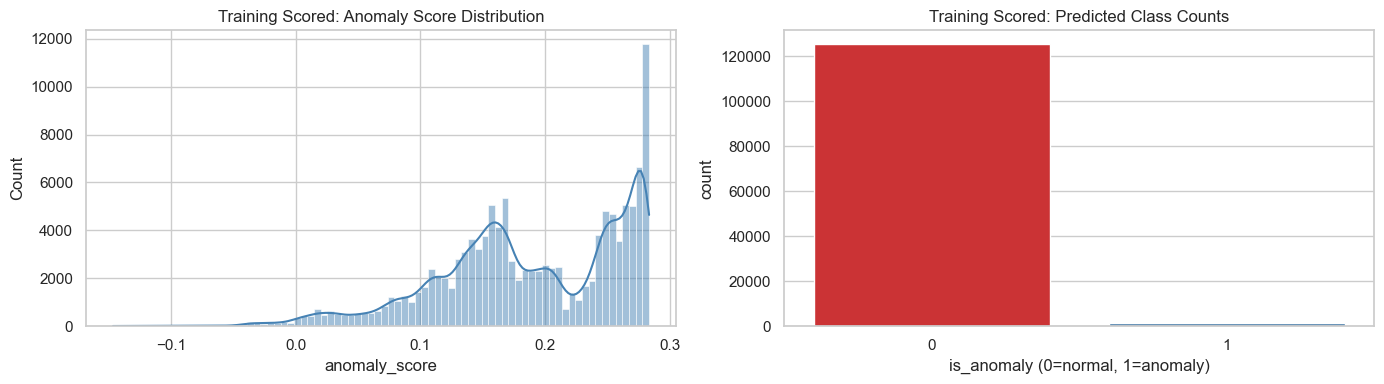

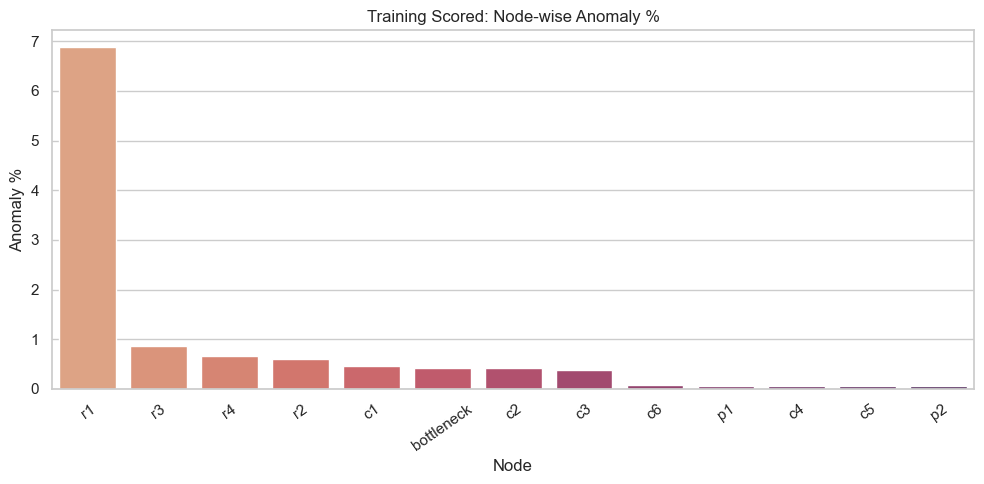

In [19]:
# 3) training_scored.csv analysis
if "timestamp" in training_scored_df.columns:
    training_scored_df["timestamp"] = pd.to_datetime(training_scored_df["timestamp"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(training_scored_df, x="anomaly_score", bins=80, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Training Scored: Anomaly Score Distribution")

sns.countplot(data=training_scored_df, x="is_anomaly", hue="is_anomaly", ax=axes[1], palette="Set1", legend=False)
axes[1].set_title("Training Scored: Predicted Class Counts")
axes[1].set_xlabel("is_anomaly (0=normal, 1=anomaly)")

plt.tight_layout()
plt.savefig(ANALYSIS_OUT / "04_training_scored_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

if "node" in training_scored_df.columns:
    node_train = (
        training_scored_df.groupby("node")
        .agg(n_samples=("is_anomaly", "size"), n_anomalies=("is_anomaly", "sum"), mean_score=("anomaly_score", "mean"))
        .reset_index()
    )
    node_train["anomaly_pct"] = node_train["n_anomalies"] / node_train["n_samples"] * 100

    plt.figure(figsize=(10, 5))
    node_train = node_train.sort_values("anomaly_pct", ascending=False)
    sns.barplot(data=node_train, x="node", y="anomaly_pct", hue="node", palette="flare", legend=False)
    plt.title("Training Scored: Node-wise Anomaly %")
    plt.xlabel("Node")
    plt.ylabel("Anomaly %")
    plt.xticks(rotation=35)
    plt.tight_layout()
    plt.savefig(ANALYSIS_OUT / "05_training_node_anomaly_pct.png", dpi=150, bbox_inches="tight")
    plt.show()

,node,n_samples,mean_score,std_score,min_score,max_score,n_anomalies,anomaly_pct,dataset
0,bottleneck,5356,0.1340,0.0426,-0.0830,0.2105,23,0.43,normal
1,c1,11563,0.1939,0.0703,-0.0459,0.2832,53,0.46,normal
2,c2,11556,0.1987,0.0661,-0.0726,0.2832,48,0.42,normal
3,c3,11564,0.2013,0.0617,-0.0830,0.2832,45,0.39,normal
4,c4,5680,0.2503,0.0395,-0.0326,0.2832,3,0.05,normal


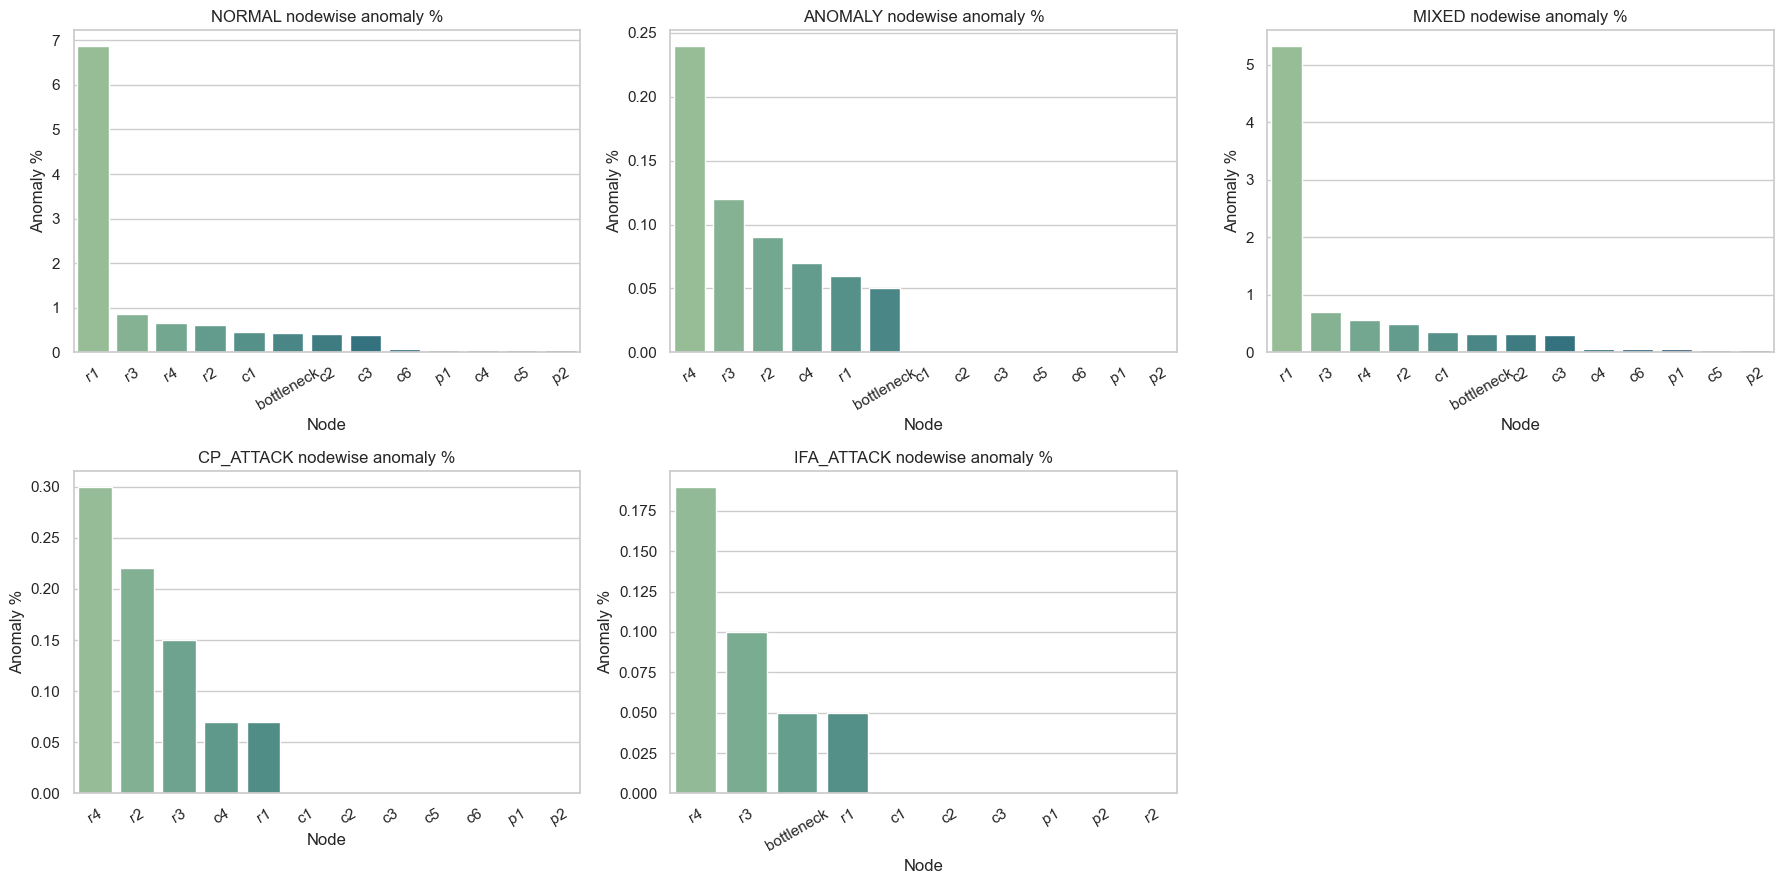

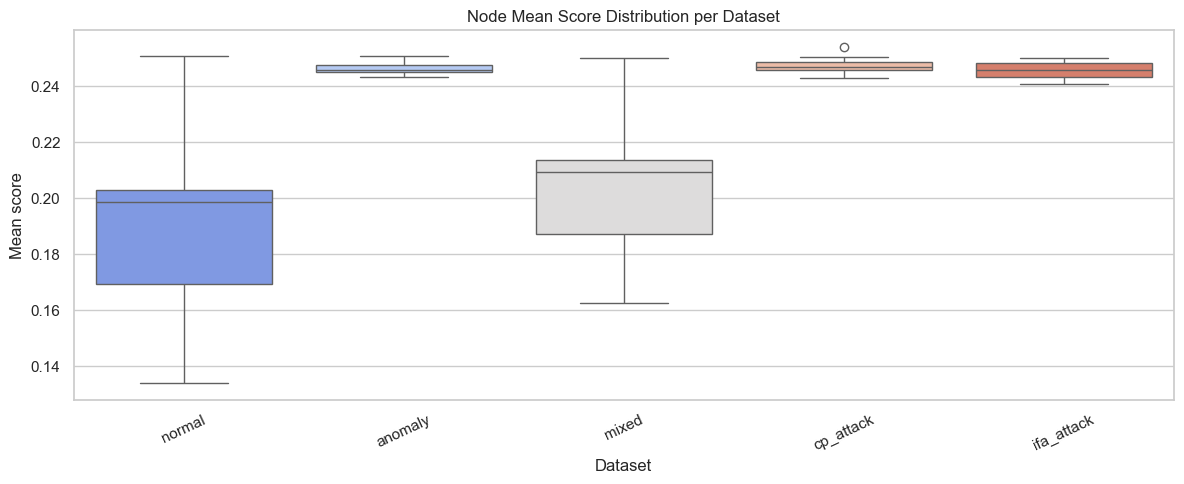

In [20]:
# 4) *_nodewise_stats.csv analysis (all datasets)
nodewise_all = []
for ds in DATASET_ORDER:
    tmp = nodewise_stats[ds].copy()
    if "node" not in tmp.columns:
        tmp = tmp.rename(columns={tmp.columns[0]: "node"})
    tmp["dataset"] = ds
    nodewise_all.append(tmp)

nodewise_all_df = pd.concat(nodewise_all, ignore_index=True)
display(nodewise_all_df.head())

# Faceted bar-like panels using subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 9), squeeze=False)
axes = axes.ravel()

for i, ds in enumerate(DATASET_ORDER):
    ax = axes[i]
    ds_df = nodewise_all_df[nodewise_all_df["dataset"] == ds].sort_values("anomaly_pct", ascending=False)
    sns.barplot(data=ds_df, x="node", y="anomaly_pct", hue="node", ax=ax, palette="crest", legend=False)
    ax.set_title(f"{ds.upper()} nodewise anomaly %")
    ax.set_xlabel("Node")
    ax.set_ylabel("Anomaly %")
    ax.tick_params(axis="x", rotation=30)

# Hide unused subplot
for j in range(len(DATASET_ORDER), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(ANALYSIS_OUT / "06_nodewise_anomaly_pct_all_datasets.png", dpi=150, bbox_inches="tight")
plt.show()

# Compare node mean score per dataset
plt.figure(figsize=(12, 5))
sns.boxplot(data=nodewise_all_df, x="dataset", y="mean_score", hue="dataset", palette="coolwarm", legend=False)
plt.title("Node Mean Score Distribution per Dataset")
plt.xlabel("Dataset")
plt.ylabel("Mean score")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(ANALYSIS_OUT / "07_nodewise_mean_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

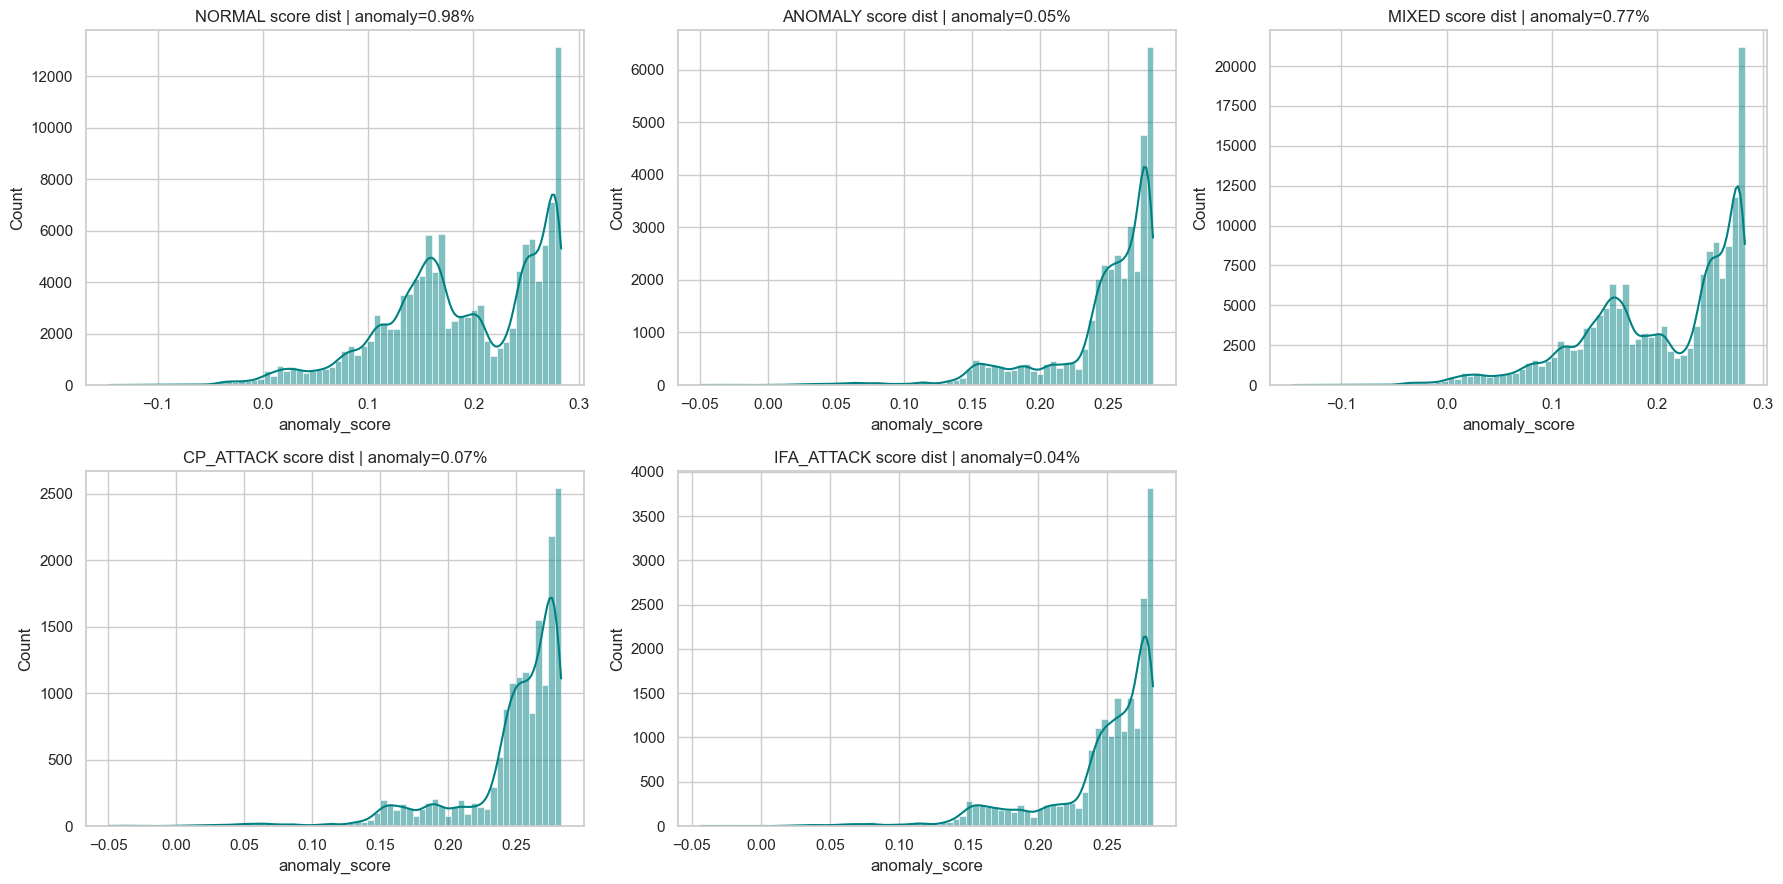

,dataset,total,anomalies,anomaly_pct
0,anomaly,36749,19,0.051702
1,cp_attack,16216,11,0.067834
2,ifa_attack,20533,8,0.038962
3,mixed,163172,1253,0.767901
4,normal,126423,1234,0.976088


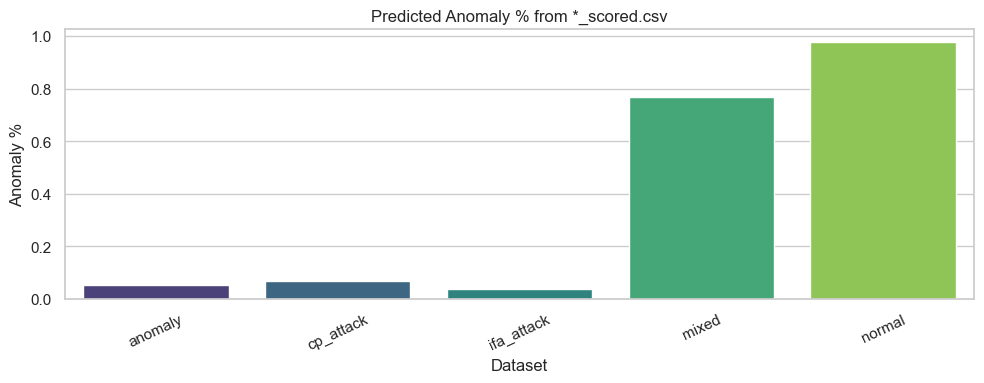

In [21]:
# 5) *_scored.csv analysis (all datasets)
scored_all = []
for ds in DATASET_ORDER:
    tmp = scored_data[ds].copy()
    tmp["dataset"] = ds
    if "timestamp" in tmp.columns:
        tmp["timestamp"] = pd.to_datetime(tmp["timestamp"], errors="coerce")
    scored_all.append(tmp)

scored_all_df = pd.concat(scored_all, ignore_index=True)

# Distribution by dataset
fig, axes = plt.subplots(2, 3, figsize=(18, 9), squeeze=False)
axes = axes.ravel()

for i, ds in enumerate(DATASET_ORDER):
    ax = axes[i]
    ds_df = scored_all_df[scored_all_df["dataset"] == ds]
    sns.histplot(ds_df["anomaly_score"], bins=70, kde=True, ax=ax, color="teal")
    anom_pct = ds_df["is_anomaly"].mean() * 100
    ax.set_title(f"{ds.upper()} score dist | anomaly={anom_pct:.2f}%")
    ax.set_xlabel("anomaly_score")

for j in range(len(DATASET_ORDER), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(ANALYSIS_OUT / "08_scored_score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Predicted class balance per dataset
class_balance = (
    scored_all_df.groupby("dataset")["is_anomaly"]
    .agg(total="size", anomalies="sum")
    .reset_index()
)
class_balance["anomaly_pct"] = class_balance["anomalies"] / class_balance["total"] * 100

display(class_balance)

plt.figure(figsize=(10, 4))
sns.barplot(data=class_balance, x="dataset", y="anomaly_pct", hue="dataset", palette="viridis", legend=False)
plt.title("Predicted Anomaly % from *_scored.csv")
plt.xlabel("Dataset")
plt.ylabel("Anomaly %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(ANALYSIS_OUT / "09_scored_anomaly_pct_by_dataset.png", dpi=150, bbox_inches="tight")
plt.show()

,feature,importance_score,dataset
0,in_interests_rate,0.033659,normal
1,out_interests_rate,0.030463,normal
2,in_data_rate,0.029724,normal
3,cs_size,0.028005,normal
4,satisfaction_ratio,0.014421,normal


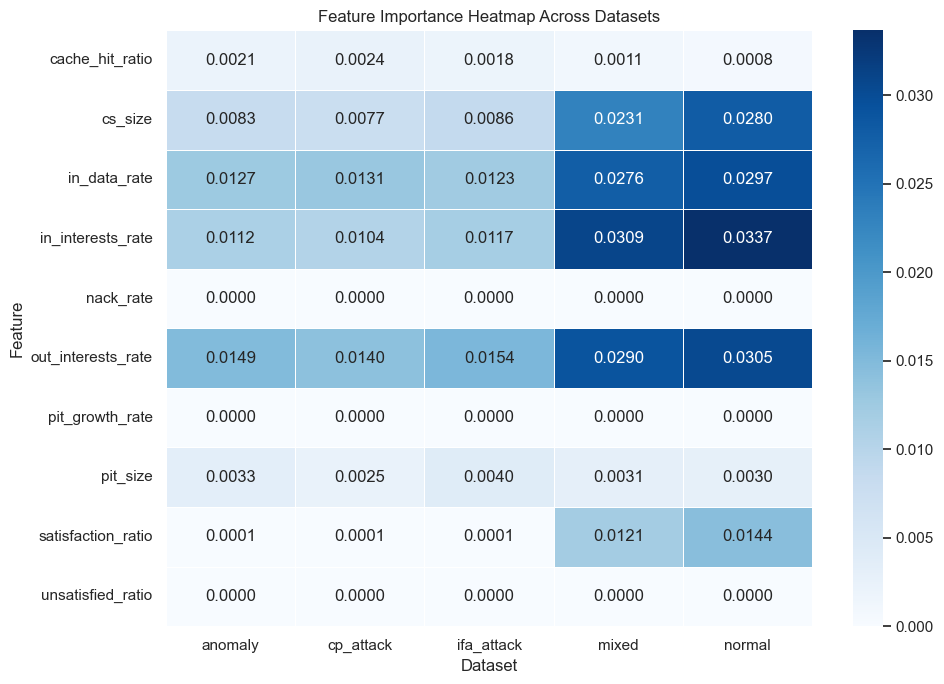

,feature,importance_score,dataset
0,in_interests_rate,0.033659,normal
1,out_interests_rate,0.030463,normal
2,in_data_rate,0.029724,normal
3,cs_size,0.028005,normal
4,satisfaction_ratio,0.014421,normal
5,out_interests_rate,0.014928,anomaly
6,in_data_rate,0.012674,anomaly
7,in_interests_rate,0.011240,anomaly
8,cs_size,0.008256,anomaly
9,pit_size,0.003303,anomaly


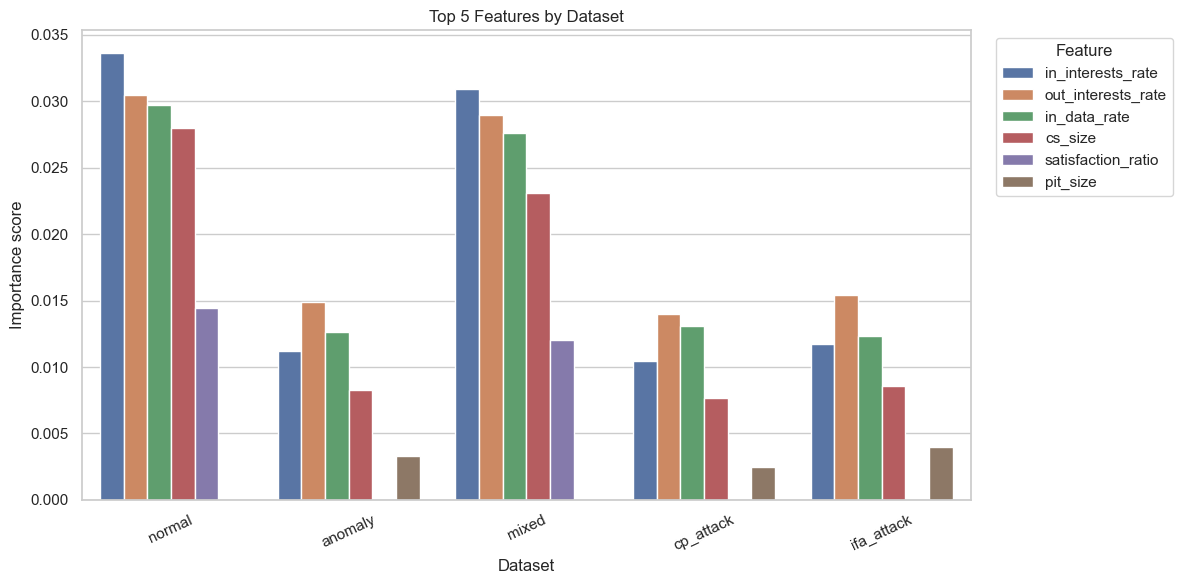

In [22]:
# 6) *_feature_importance.csv analysis (all datasets)
fi_all = []
for ds in DATASET_ORDER:
    tmp = feature_importance[ds].copy()
    tmp["dataset"] = ds
    fi_all.append(tmp)
fi_all_df = pd.concat(fi_all, ignore_index=True)

display(fi_all_df.head())

# Heatmap of feature importance
fi_heat = fi_all_df.pivot_table(index="feature", columns="dataset", values="importance_score", aggfunc="mean")

plt.figure(figsize=(10, 7))
sns.heatmap(fi_heat, annot=True, fmt=".4f", cmap="Blues", linewidths=0.4)
plt.title("Feature Importance Heatmap Across Datasets")
plt.xlabel("Dataset")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(ANALYSIS_OUT / "10_feature_importance_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Top-N feature ranking comparison
TOP_N = 5
rank_rows = []
for ds in DATASET_ORDER:
    top = feature_importance[ds].sort_values("importance_score", ascending=False).head(TOP_N).copy()
    top["dataset"] = ds
    rank_rows.append(top)

rank_df = pd.concat(rank_rows, ignore_index=True)
display(rank_df)

plt.figure(figsize=(12, 6))
sns.barplot(data=rank_df, x="dataset", y="importance_score", hue="feature")
plt.title(f"Top {TOP_N} Features by Dataset")
plt.xlabel("Dataset")
plt.ylabel("Importance score")
plt.xticks(rotation=25)
plt.legend(title="Feature", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(ANALYSIS_OUT / "11_top_feature_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

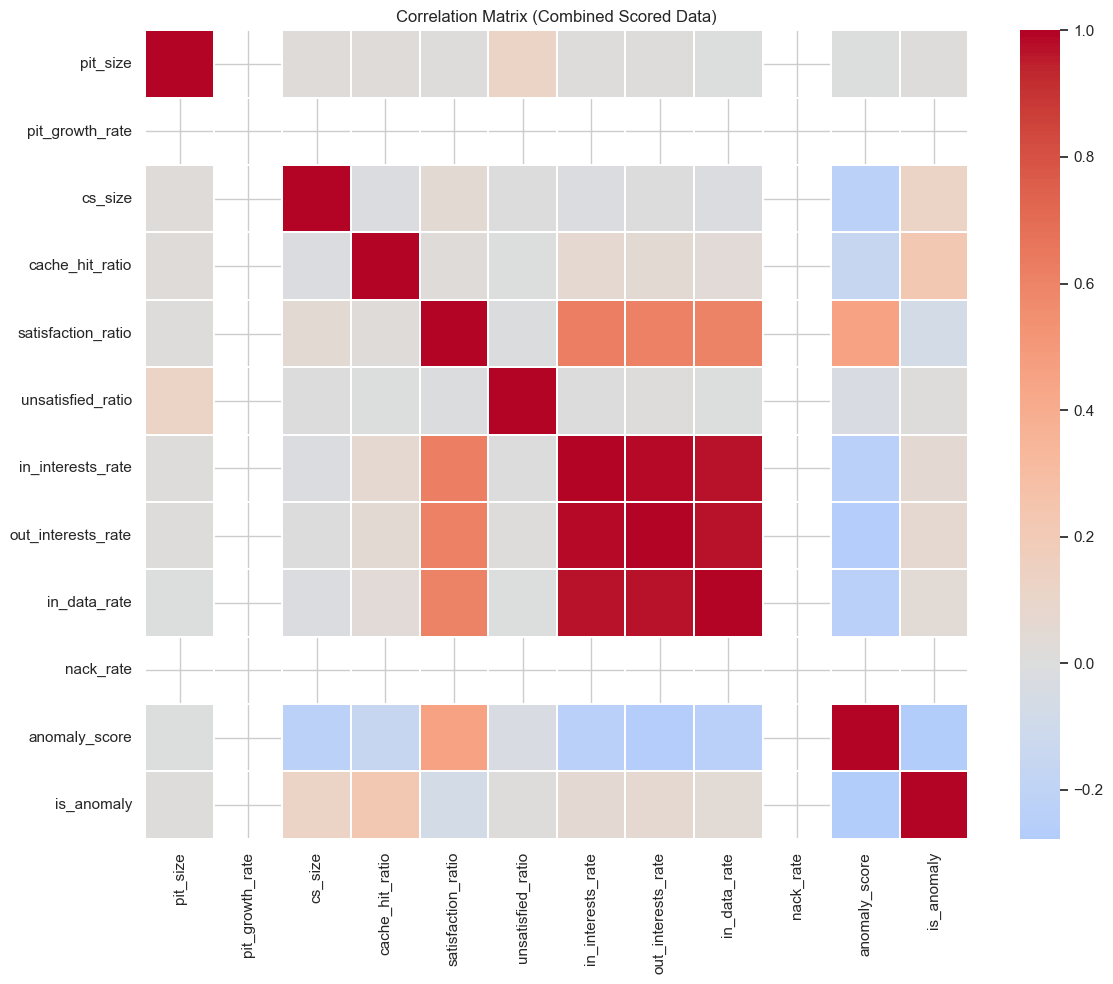

,dataset,feature,abs_mean_gap
12,anomaly,cs_size,33.974118
17,anomaly,out_interests_rate,3.119987
16,anomaly,in_interests_rate,2.940146
18,anomaly,in_data_rate,1.917271
10,anomaly,pit_size,0.892940
32,cp_attack,cs_size,49.552175
37,cp_attack,out_interests_rate,3.514245
36,cp_attack,in_interests_rate,3.101484
38,cp_attack,in_data_rate,2.180000
30,cp_attack,pit_size,0.815960


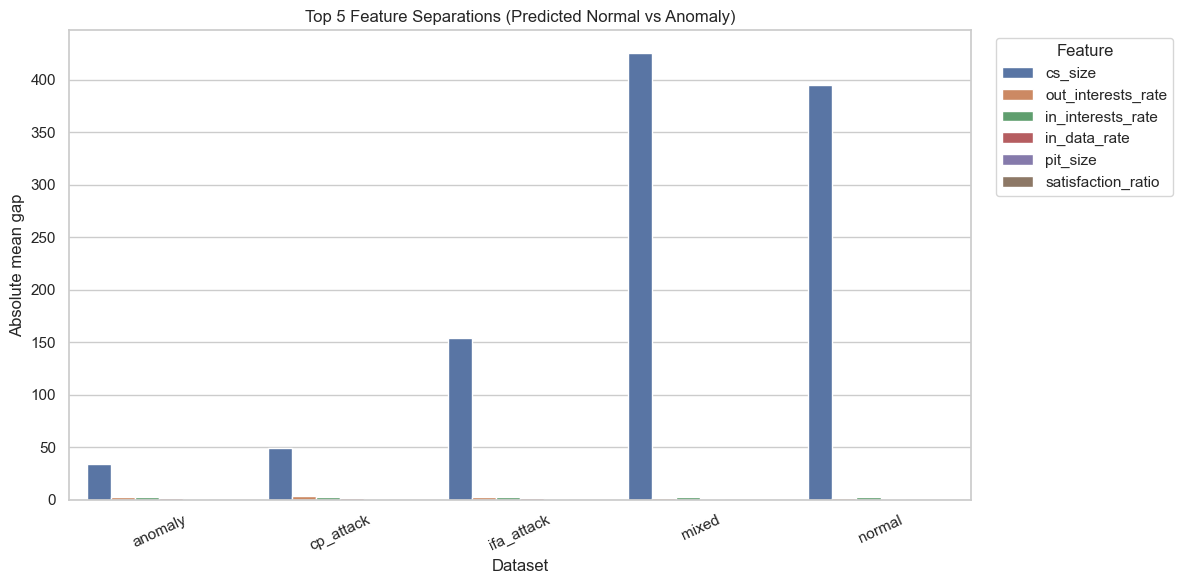

In [23]:
# 7) Correlation and separability diagnostics from all *_scored.csv files
if "is_anomaly" in scored_all_df.columns:
    num_cols = [c for c in scored_all_df.columns if c not in ["dataset", "node", "timestamp"]]
    corr_cols = [c for c in num_cols if pd.api.types.is_numeric_dtype(scored_all_df[c])]

    corr_df = scored_all_df[corr_cols].corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_df, cmap="coolwarm", center=0, linewidths=0.2)
    plt.title("Correlation Matrix (Combined Scored Data)")
    plt.tight_layout()
    plt.savefig(ANALYSIS_OUT / "12_scored_correlation_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Feature separation score (difference in means between predicted normal vs anomaly)
    sep_rows = []
    for ds in DATASET_ORDER:
        ds_df = scored_data[ds].copy()
        for col in ds_df.columns:
            if col in ["is_anomaly", "anomaly_score", "node", "timestamp"]:
                continue
            if pd.api.types.is_numeric_dtype(ds_df[col]):
                mean0 = ds_df.loc[ds_df["is_anomaly"] == 0, col].mean()
                mean1 = ds_df.loc[ds_df["is_anomaly"] == 1, col].mean()
                sep = abs(mean1 - mean0)
                sep_rows.append({"dataset": ds, "feature": col, "abs_mean_gap": sep})

    sep_df = pd.DataFrame(sep_rows)
    top_sep = sep_df.sort_values(["dataset", "abs_mean_gap"], ascending=[True, False]).groupby("dataset").head(5)
    display(top_sep)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_sep, x="dataset", y="abs_mean_gap", hue="feature")
    plt.title("Top 5 Feature Separations (Predicted Normal vs Anomaly)")
    plt.xlabel("Dataset")
    plt.ylabel("Absolute mean gap")
    plt.xticks(rotation=25)
    plt.legend(title="Feature", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(ANALYSIS_OUT / "13_feature_separation_top5.png", dpi=150, bbox_inches="tight")
    plt.show()

In [24]:
# 8) Build an analysis summary table and save it
summary_insights = summary_df.copy()
summary_insights = summary_insights.sort_values("anomaly_pct", ascending=False)
summary_insights["score_range"] = summary_insights["min_score"].round(4).astype(str) + " to " + summary_insights["max_score"].round(4).astype(str)

# Merge with class_balance from scored files
summary_final = summary_insights.merge(
    class_balance[["dataset", "anomaly_pct"]].rename(columns={"dataset": "dataset_name", "anomaly_pct": "scored_anomaly_pct"}),
    on="dataset_name",
    how="left"
)

summary_final = summary_final[[
    "dataset_name", "n_samples", "n_nodes", "n_anomalies", "anomaly_pct", "scored_anomaly_pct",
    "mean_score", "std_score", "score_range", "threshold"
]]

display(summary_final)

summary_final.to_csv(ANALYSIS_OUT / "analysis_summary_table.csv", index=False)
print("Saved analysis summary CSV ->", ANALYSIS_OUT / "analysis_summary_table.csv")

# List all generated analysis charts
generated = sorted(glob.glob(str(ANALYSIS_OUT / "*.png")))
print("\nGenerated chart files:")
for g in generated:
    print("-", Path(g).name)

,dataset_name,n_samples,n_nodes,n_anomalies,anomaly_pct,scored_anomaly_pct,mean_score,std_score,score_range,threshold
0,normal,126423,13,1234,0.976088,0.976088,0.188531,0.073374,-0.1462 to 0.2832,0.0
1,mixed,163172,13,1253,0.767901,0.767901,0.201557,0.071836,-0.1462 to 0.2832,0.0
2,cp_attack,16216,12,11,0.067834,0.067834,0.247390,0.041661,-0.0494 to 0.2832,0.0
3,anomaly,36749,13,19,0.051702,0.051702,0.246366,0.042431,-0.0494 to 0.2832,0.0
4,ifa_attack,20533,10,8,0.038962,0.038962,0.245558,0.043012,-0.0435 to 0.2832,0.0


Saved analysis summary CSV -> ../Results/analysis_charts/analysis_summary_table.csv

Generated chart files:
- 01_dataset_summary_bars.png
- 02_node_dataset_anomaly_heatmap.png
- 03_node_mean_score_boxplot.png
- 04_training_scored_distribution.png
- 05_training_node_anomaly_pct.png
- 06_nodewise_anomaly_pct_all_datasets.png
- 07_nodewise_mean_score_distribution.png
- 08_scored_score_distributions.png
- 09_scored_anomaly_pct_by_dataset.png
- 10_feature_importance_heatmap.png
- 11_top_feature_comparison.png
- 12_scored_correlation_matrix.png
- 13_feature_separation_top5.png
